**You are the average of the five people you spend the most time with.    - Jim Rohn**

The Quote: Suggests that an individual is shaped by the influences of the people closest to them.

k-NN Algorithm: Determines the class or value of a data point based on the characteristics of its closest neighbors in the feature space.

In both cases, proximity to a group influences the outcome:

In the quote, proximity is in terms of relationships or time spent.

In k-NN, proximity is in terms of Euclidean distance (or another metric) in a feature space.

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

In [2]:
# Load Data
df_original = pd.read_csv('Children Recode_final.csv')

# Drop unnecessary columns
df = df_original.drop(['Underweight', 'Wasting'], axis=1)

# Feature and Target selection
X = df.drop(columns=['Stunting'])
y = df['Stunting']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN Model
knn = KNeighborsClassifier(n_neighbors=19)
knn.fit(X_train, y_train)

# Predictions & Accuracy
predictions = knn.predict(X_test)
accuracy = knn.score(X_test, y_test)

accuracy


0.7745535714285714

In [4]:
df_original.head()

,Underweight,Stunting,Wasting,Child_age,Mother_education,Age_first_sex,Pregnancy_terminated,Wealth_index,Place_residence,BMI,...,Religion_5,Ethnicity_2,Ethnicity_3,Ethnicity_4,Ethnicity_5,Ethnicity_6,Ethnicity_7,Ethnicity_8,Ethnicity_9,Ethnicity_10
0,0,0,0,17,1,14,0,1,2,22.00,...,0,1,0,0,0,0,0,0,0,0
1,0,1,0,40,2,17,1,2,2,25.10,...,0,0,0,0,0,0,0,1,0,0
2,0,1,0,59,2,17,1,2,2,25.10,...,0,0,0,0,0,0,0,1,0,0
3,1,1,0,55,2,17,0,2,2,21.53,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,14,1,16,0,1,2,28.03,...,0,0,0,0,0,0,0,1,0,0


## Stunting Prediction

In [4]:
columns_to_scale = ['Child_age', 'Age_first_sex', 'BMI', 'Mother_age_current', 'Mother_age_at_first_birth']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test_scaled[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [40]:
knn_scaled = KNeighborsClassifier()
knn_scaled.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [41]:
predictions_scaled = knn_scaled.predict(X_test_scaled)
accuracy_scaled = knn_scaled.score(X_test_scaled, y_test)
print(f'Accuracy: {accuracy_scaled}')
confusion_matrix(y_test, predictions_scaled)

Accuracy: 0.8571428571428571


array([[332,  11],
       [ 53,  52]])

### K-value for the best performance

In [31]:
# Manual method
k_range = range(1, 31)
accuracy_scores = []

# Peform cross-validation for each k
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv = 5, scoring = 'accuracy') # 5 fold cross-validation
    accuracy_scores.append(scores.mean())

best_k = k_range[np.argmax(accuracy_scores)]
print(f"Best k value: {best_k}")

Best k value: 11


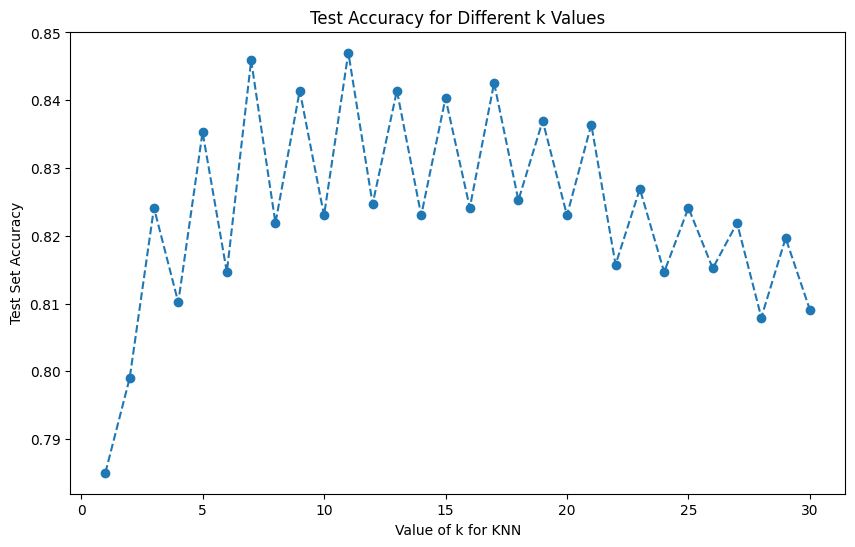

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracy_scores, marker='o', linestyle='--')
plt.xlabel('Value of k for KNN')
plt.ylabel('Test Set Accuracy')
plt.title('Test Accuracy for Different k Values')
plt.show()

In [ ]:
# # Using GridSearchCV
# knn = KNeighborsClassifier()

# # Define the grid of k values
# param_grid = {'n_neighbors': range(1, 31)}

# # Perform grid search with cross-validation
# grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
# grid_search.fit(X_train_scaled, y_train)

# # Best k value
# print("Best k:", grid_search.best_params_['n_neighbors'])
# print("Best accuracy:", grid_search.best_score_)


Best k: 11
Best accuracy: 0.847011406607429


Even thoufh best k value received is 11, the default k = 5 works better for accuracy.

In [13]:
# Synthetic Minority Oversampling Technique (SMOTE)

y.value_counts()

Stunting
0    1660
1     579
Name: count, dtype: int64

1. why do the k=11 has less accuracy
2. 